# EDA: Pantau Pasar
Eksplorasi data PIHPS (Jan 2022 - Apr 2026), 21 komoditas pangan strategis nasional.
Model AI akan ditraining dengan data ini, jadi EDA ini sekaligus jadi panduan untuk feature engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_rows', 30)

In [2]:
df = pd.read_csv('data/cleaned/pihps_cleaned.csv', parse_dates=['tanggal'])

print(f'Shape          : {df.shape}')
print(f'Rentang tanggal: {df.tanggal.min().date()} s/d {df.tanggal.max().date()}')
print(f'Komoditas      : {df.Komoditas.nunique()}')
print(f'Missing values : {df.isna().sum().sum()}')
df.head()

Shape          : (23709, 5)
Rentang tanggal: 2022-01-03 s/d 2026-04-30
Komoditas      : 21
Missing values : 0


,Komoditas,tanggal,harga,sumber,is_outlier
0,Bawang Merah Ukuran Sedang,2022-01-03,"30,200",PIHPS,False
1,Bawang Merah Ukuran Sedang,2022-01-04,"30,150",PIHPS,False
2,Bawang Merah Ukuran Sedang,2022-01-05,"30,300",PIHPS,False
3,Bawang Merah Ukuran Sedang,2022-01-06,"30,300",PIHPS,False
4,Bawang Merah Ukuran Sedang,2022-01-07,"30,400",PIHPS,False


In [3]:
KATEGORI = {
    'Beras': [c for c in df.Komoditas.unique() if 'Beras' in c],
    'Cabai': [c for c in df.Komoditas.unique() if 'Cabai' in c],
    'Daging & Telur': [c for c in df.Komoditas.unique() if 'Daging' in c or 'Telur' in c],
    'Bawang': [c for c in df.Komoditas.unique() if 'Bawang' in c],
    'Minyak Goreng': [c for c in df.Komoditas.unique() if 'Minyak' in c],
    'Gula': [c for c in df.Komoditas.unique() if 'Gula' in c],
}

RAMADAN = [
    ('2022-04-02', '2022-05-01'),
    ('2023-03-23', '2023-04-21'),
    ('2024-03-11', '2024-04-09'),
    ('2025-03-01', '2025-03-30'),
]

def add_ramadan_shade(ax):
    for start, end in RAMADAN:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color='gold', zorder=0)

def shorten(name):
    return (name.replace('Kualitas ', '')
                .replace('Ukuran ', '')
                .replace(' Bermerk', '')
                .replace(' Kemasan', ''))

for kat, lst in KATEGORI.items():
    print(f'{kat}: {lst}')

Beras: ['Beras Kualitas Bawah I', 'Beras Kualitas Bawah II', 'Beras Kualitas Medium I', 'Beras Kualitas Medium II', 'Beras Kualitas Super I', 'Beras Kualitas Super II']
Cabai: ['Cabai Merah Besar', 'Cabai Merah Keriting', 'Cabai Rawit Hijau', 'Cabai Rawit Merah']
Daging & Telur: ['Daging Ayam Ras Segar', 'Daging Sapi Kualitas 1', 'Daging Sapi Kualitas 2', 'Telur Ayam Ras Segar']
Bawang: ['Bawang Merah Ukuran Sedang', 'Bawang Putih Ukuran Sedang']
Minyak Goreng: ['Minyak Goreng Curah', 'Minyak Goreng Kemasan Bermerk 1', 'Minyak Goreng Kemasan Bermerk 2']
Gula: ['Gula Pasir Kualitas Premium', 'Gula Pasir Lokal']


## 1. Coverage Data per Komoditas
Cek apakah tiap komoditas punya jumlah hari observasi yang seimbang atau ada yang sparse.

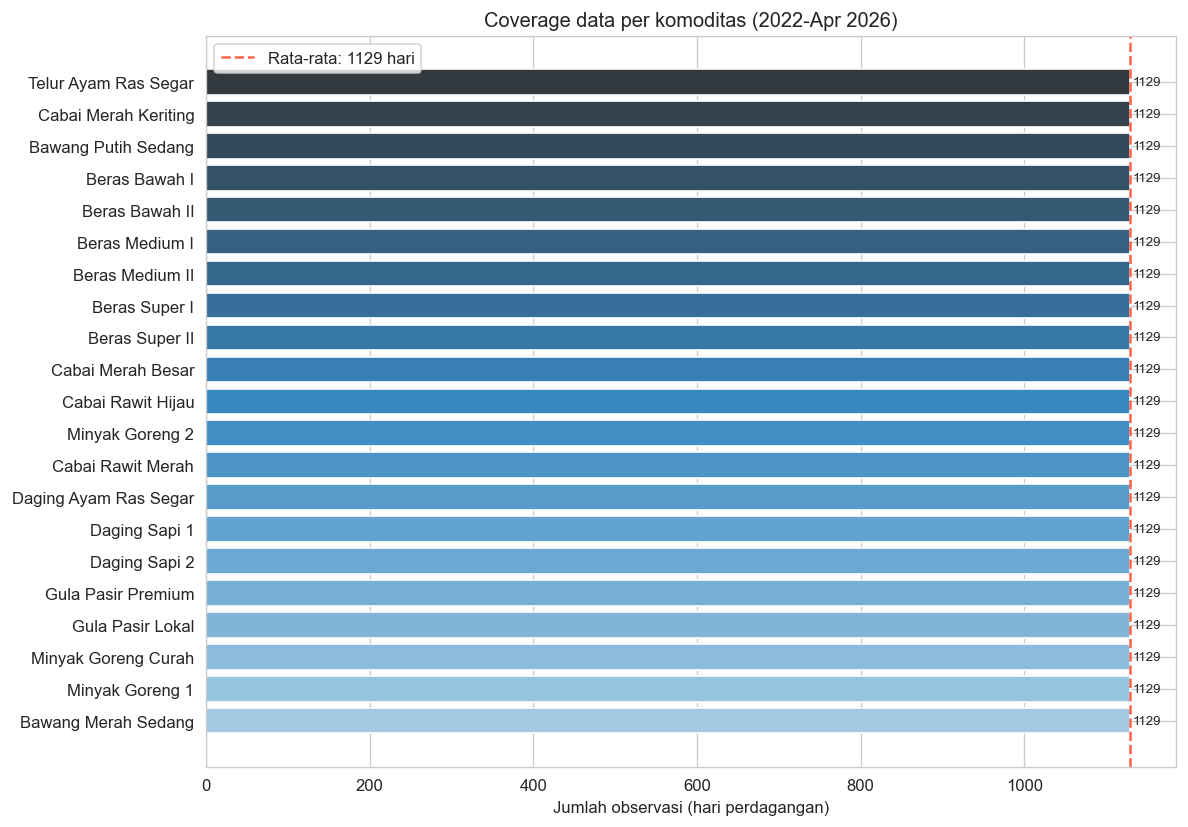

Min: 1129 | Max: 1129 | Std: 0.0
Semua komoditas punya jumlah hari yang sama, tidak ada yang sparse.


In [4]:
counts = df.groupby('Komoditas').size().sort_values()
labels = [shorten(c) for c in counts.index]

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('Blues_d', len(counts))
bars = ax.barh(labels, counts.values, color=colors)
ax.axvline(counts.mean(), ls='--', color='tomato', lw=1.5,
           label=f'Rata-rata: {counts.mean():.0f} hari')
ax.set_xlabel('Jumlah observasi (hari perdagangan)')
ax.set_title('Coverage data per komoditas (2022-Apr 2026)')
ax.legend()
for bar, val in zip(bars, counts.values):
    ax.text(val + 3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Min: {counts.min()} | Max: {counts.max()} | Std: {counts.std():.1f}')
print('Semua komoditas punya jumlah hari yang sama, tidak ada yang sparse.')

## 2. Statistik Deskriptif
Diurutkan berdasarkan volatilitas (CV = Std/Mean). Komoditas dengan CV tinggi lebih sulit diprediksi model.

In [5]:
stats = df.groupby('Komoditas')['harga'].agg(['mean', 'median', 'std', 'min', 'max']).round(1)
stats['CV (%)'] = (stats['std'] / stats['mean'] * 100).round(1)
stats.columns = ['Rata-rata', 'Median', 'Std Dev', 'Min', 'Max', 'CV (%)']
stats.index = [shorten(c) for c in stats.index]
stats = stats.sort_values('CV (%)', ascending=False)
stats

,Rata-rata,Median,Std Dev,Min,Max,CV (%)
Cabai Rawit Merah,"62,297","58,650","14,952","35,500","105,000",24
Cabai Merah Keriting,"51,080","49,750","10,540","31,000","90,350",21
Cabai Merah Besar,"50,788","49,150","10,274","19,000","87,500",20
Bawang Merah Sedang,"40,560","40,500","7,436","26,000","64,800",18
Cabai Rawit Hijau,"49,094","47,950","8,217","22,000","78,700",17
Bawang Putih Sedang,"38,303","40,000","5,796","24,000","48,100",15
Beras Bawah II,"12,880","13,750","1,491","10,350","14,550",12
Beras Medium II,"14,178","15,150","1,575","11,350","16,250",11
Beras Bawah I,"13,105","13,950","1,428","10,000","14,800",11
Gula Pasir Lokal,"16,663","17,750","1,813","13,350","19,250",11


## 3. Tren Harga per Kategori
Data di-resample mingguan untuk mengurangi noise. Area kuning = periode Ramadan.

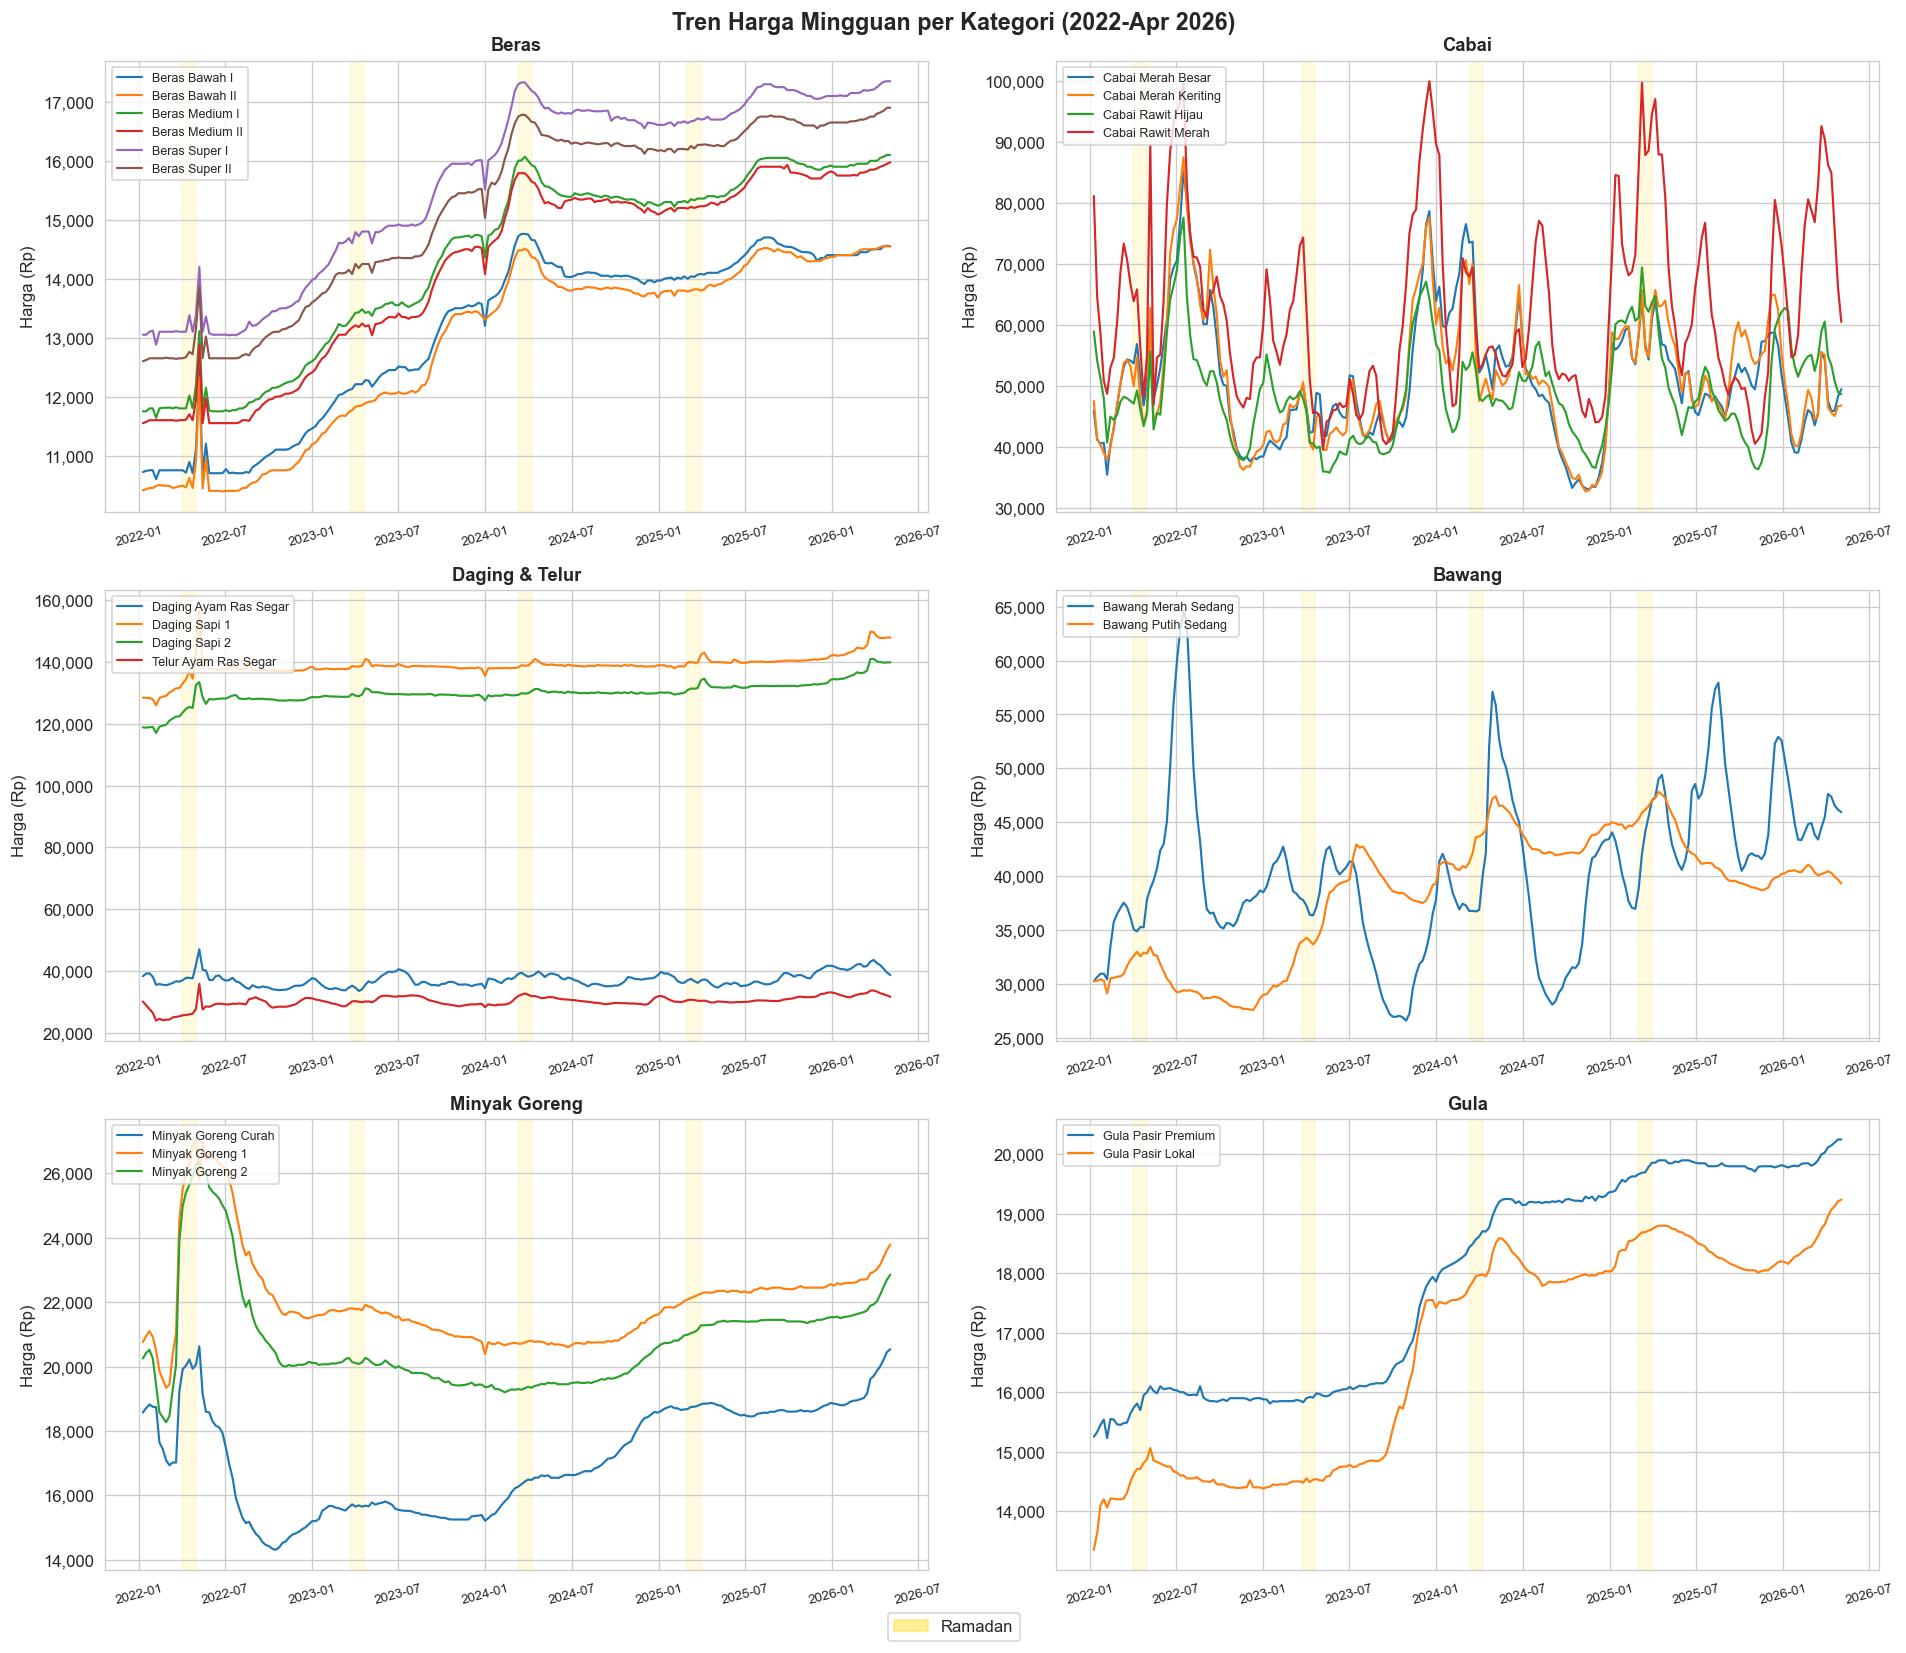

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (kat, kom_list) in enumerate(KATEGORI.items()):
    ax = axes[idx]
    subset = df[df.Komoditas.isin(kom_list)]
    for kom in sorted(kom_list):
        data = (subset[subset.Komoditas == kom]
                .set_index('tanggal')['harga']
                .resample('W').mean())
        ax.plot(data.index, data.values, label=shorten(kom), linewidth=1.3)
    add_ramadan_shade(ax)
    ax.set_title(kat, fontweight='bold', fontsize=11)
    ax.set_ylabel('Harga (Rp)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=7.5, loc='upper left')
    ax.tick_params(axis='x', rotation=15, labelsize=8)

ramadan_patch = mpatches.Patch(color='gold', alpha=0.4, label='Ramadan')
fig.legend(handles=[ramadan_patch], loc='lower center', bbox_to_anchor=(0.5, 0.005))
fig.suptitle('Tren Harga Mingguan per Kategori (2022-Apr 2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

## 4. Pola Musiman
Panel kiri: z-score harga bulanan untuk komoditas paling volatile, lihat bulan mana yang konsisten tinggi.
Panel kanan: perubahan harga rata-rata tahunan vs baseline 2022 (kolom 2026 = Jan-Apr saja).

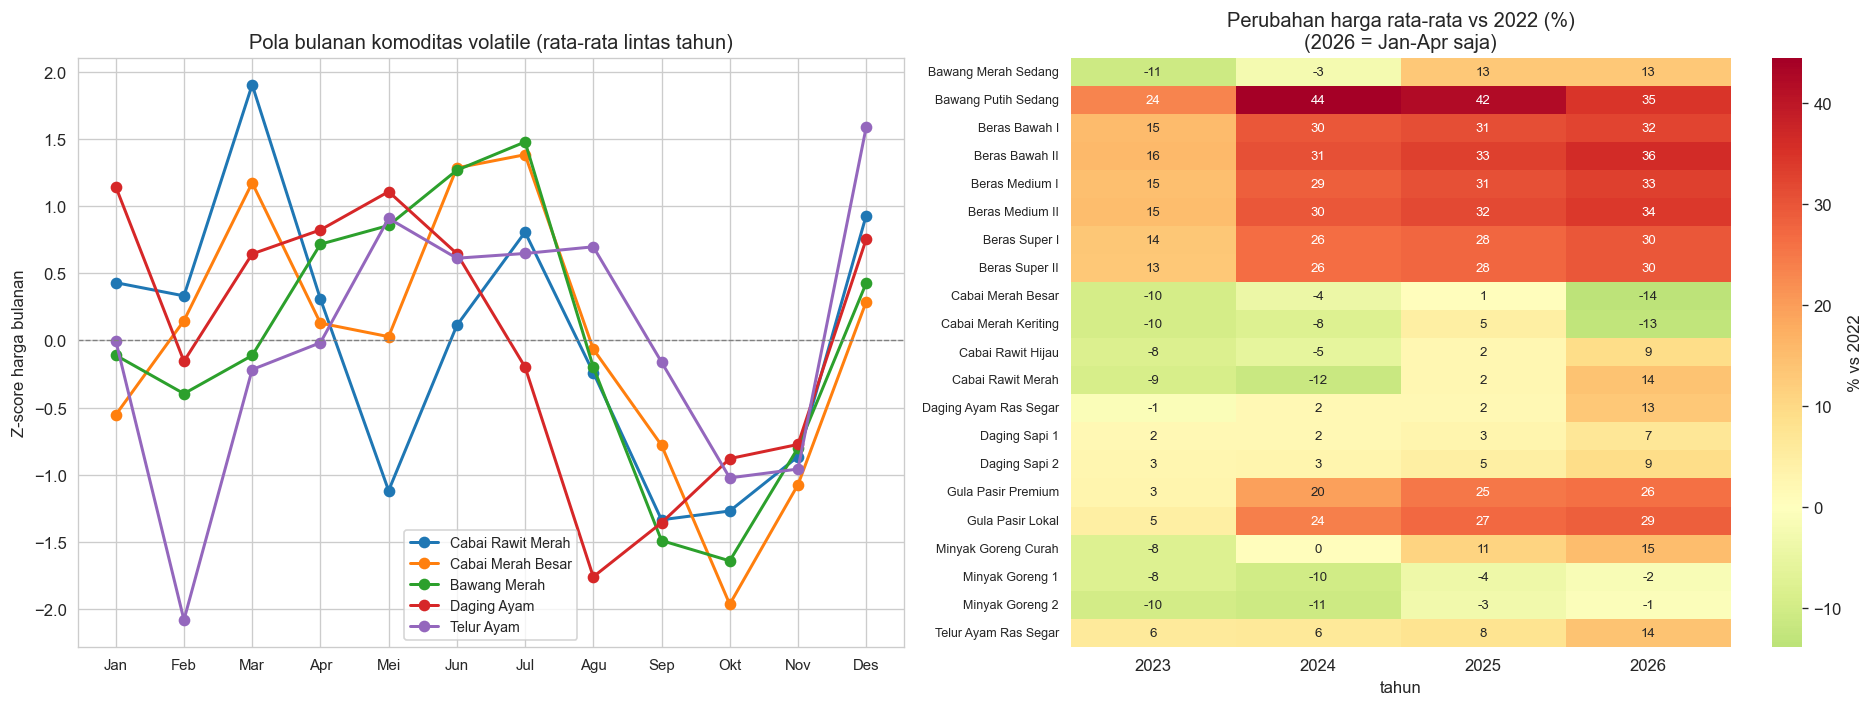

In [7]:
df['bulan'] = df.tanggal.dt.month
df['tahun'] = df.tanggal.dt.year

volatile = [
    'Cabai Rawit Merah', 'Cabai Merah Besar',
    'Bawang Merah Ukuran Sedang', 'Daging Ayam Ras Segar', 'Telur Ayam Ras Segar',
]
bulan_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for kom in volatile:
    monthly = df[df.Komoditas == kom].groupby('bulan')['harga'].mean()
    z = (monthly - monthly.mean()) / monthly.std()
    ax.plot(monthly.index, z.values, marker='o', linewidth=1.8,
            label=kom.replace(' Ukuran Sedang', '').replace(' Ras Segar', ''))
ax.axhline(0, ls='--', color='gray', lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(bulan_label, fontsize=9)
ax.set_ylabel('Z-score harga bulanan')
ax.set_title('Pola bulanan komoditas volatile (rata-rata lintas tahun)')
ax.legend(fontsize=8.5)

ax = axes[1]
yoy = df.groupby(['tahun', 'Komoditas'])['harga'].mean().unstack('tahun')
yoy_pct = yoy.div(yoy[2022], axis=0).sub(1).mul(100).drop(columns=2022).round(1)
yoy_pct.index = [shorten(c) for c in yoy_pct.index]
sns.heatmap(yoy_pct, annot=True, fmt='.0f', cmap='RdYlGn_r', center=0,
            annot_kws={'size': 8}, ax=ax, cbar_kws={'label': '% vs 2022'})
ax.set_title('Perubahan harga rata-rata vs 2022 (%)\n(2026 = Jan-Apr saja)')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7.5)

plt.tight_layout()
plt.show()

## 5. Korelasi antar Komoditas
Data di-resample mingguan sebelum dihitung korelasinya untuk mengurangi noise harian.

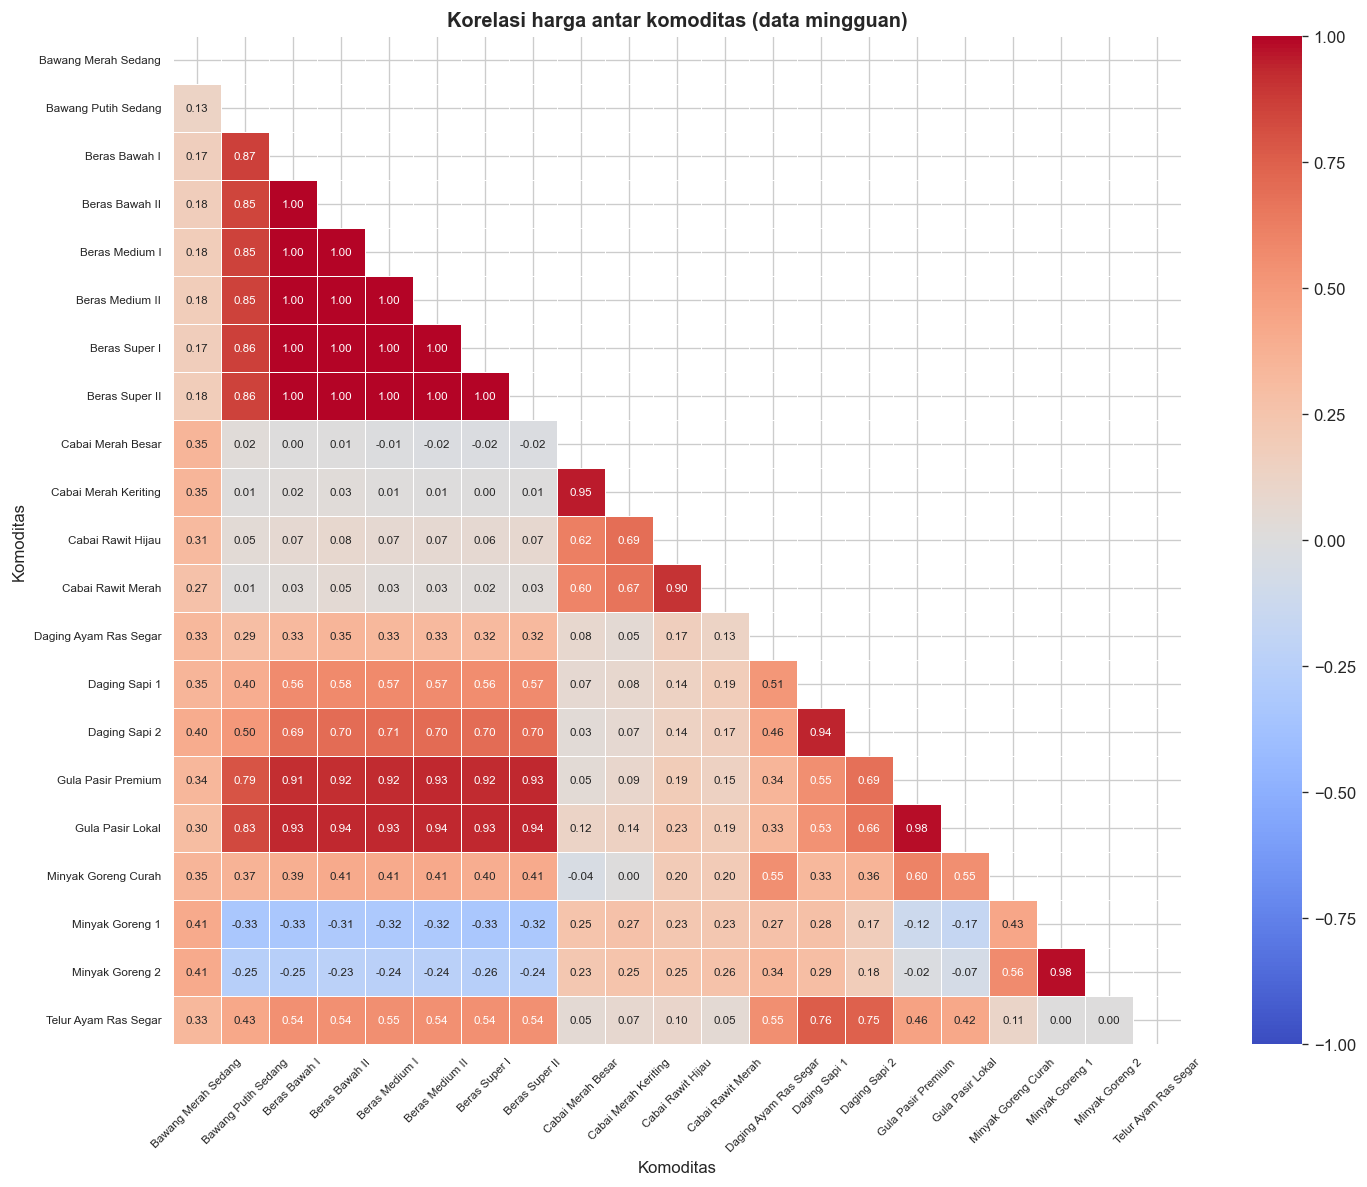

In [8]:
pivot = (df.pivot_table(index='tanggal', columns='Komoditas', values='harga')
           .resample('W').mean())
corr = pivot.corr()
short_names = {c: shorten(c) for c in corr.columns}
corr = corr.rename(index=short_names, columns=short_names)

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, annot_kws={'size': 7}, ax=ax,
            linewidths=0.3, square=True)
ax.set_title('Korelasi harga antar komoditas (data mingguan)', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.show()

## 6. Distribusi Harga (Boxplot)
Outlier tampil sebagai titik di luar whisker, ini memang data asli, tidak dihapus.

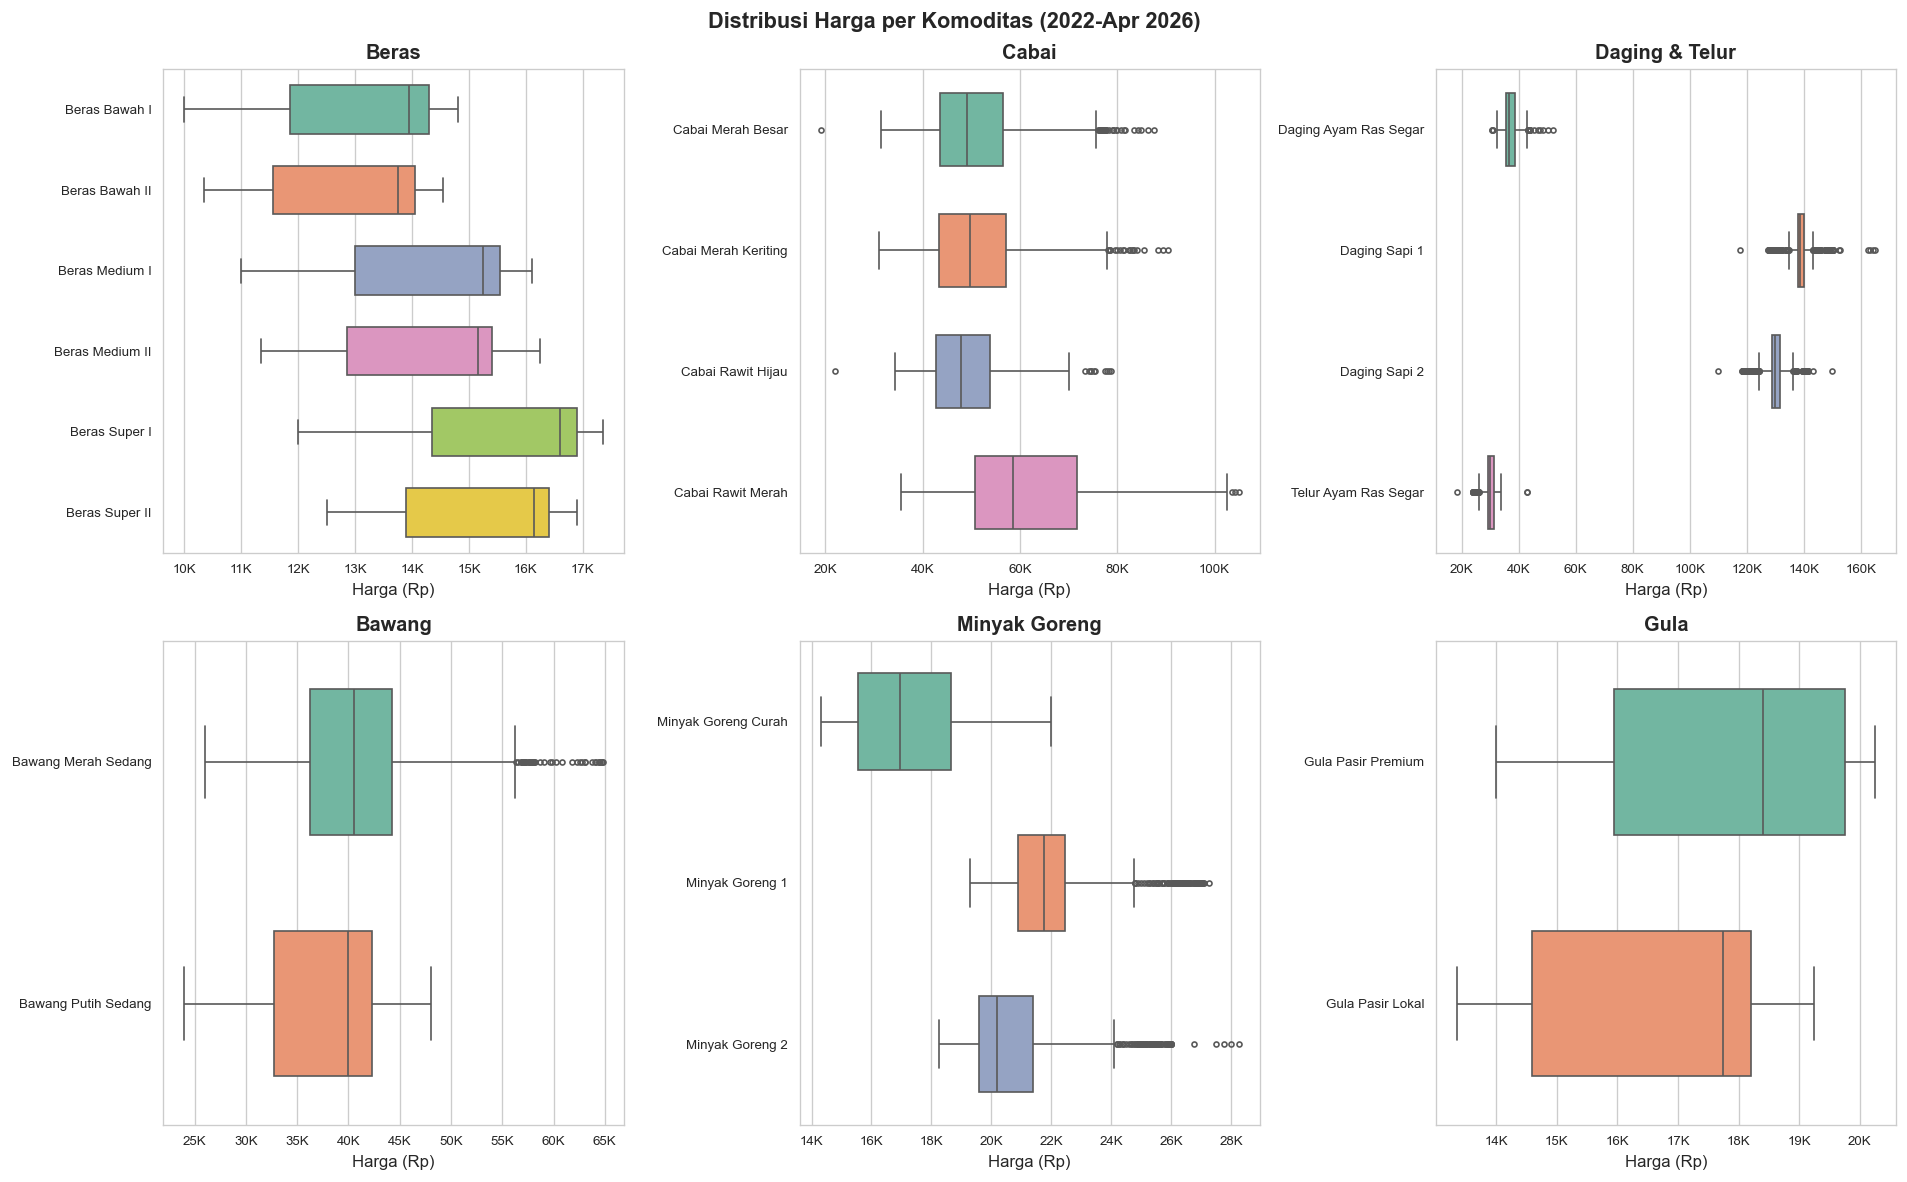

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (kat, kom_list) in enumerate(KATEGORI.items()):
    ax = axes[idx]
    subset = df[df.Komoditas.isin(kom_list)].copy()
    subset['label'] = subset.Komoditas.apply(shorten)
    sns.boxplot(data=subset, y='label', x='harga', ax=ax, palette='Set2',
                orient='h', width=0.6, flierprops={'markersize': 3})
    ax.set_title(kat, fontweight='bold')
    ax.set_xlabel('Harga (Rp)')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.tick_params(labelsize=8)

plt.suptitle('Distribusi Harga per Komoditas (2022-Apr 2026)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Analisis Outlier
Outlier dideteksi dengan IQR x 1.5 per komoditas dan sudah di-flag di kolom `is_outlier`.
Tidak dihapus, lonjakan Ramadan/Lebaran adalah sinyal valid untuk model.

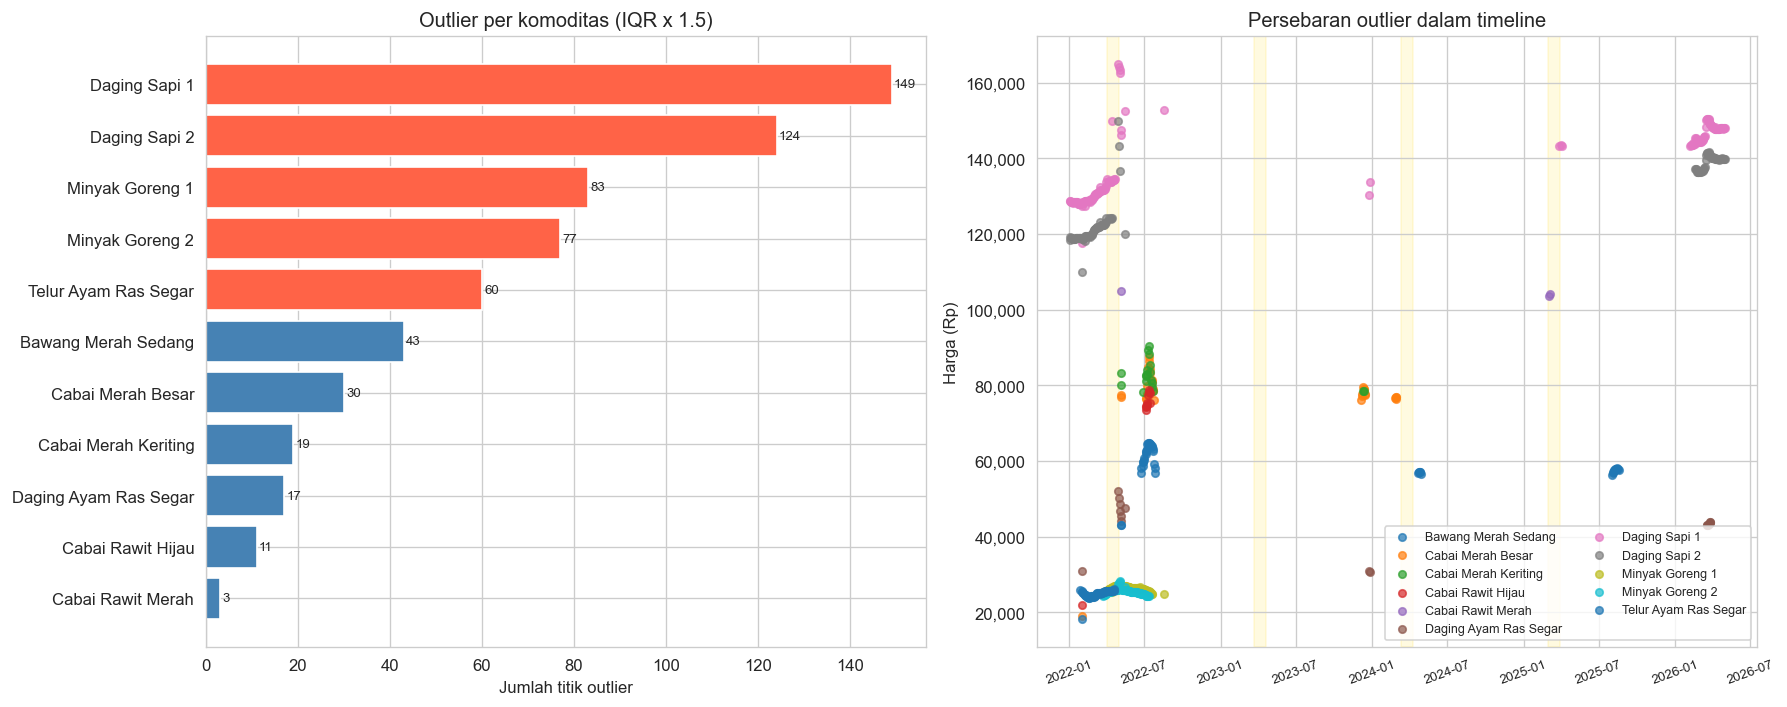

Total outlier: 616 dari 23,709 baris (2.60%)


In [10]:
outlier_df = df[df.is_outlier]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
outlier_count = outlier_df.groupby('Komoditas').size().sort_values(ascending=True)
short_labels = [shorten(c) for c in outlier_count.index]
bar_colors = ['tomato' if v > 50 else 'steelblue' for v in outlier_count.values]
bars = ax.barh(short_labels, outlier_count.values, color=bar_colors)
ax.set_xlabel('Jumlah titik outlier')
ax.set_title('Outlier per komoditas (IQR x 1.5)')
for bar, val in zip(bars, outlier_count.values):
    if val > 0:
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=8)

ax = axes[1]
pal = sns.color_palette('tab10', outlier_df.Komoditas.nunique())
for i, kom in enumerate(sorted(outlier_df.Komoditas.unique())):
    sub = outlier_df[outlier_df.Komoditas == kom]
    ax.scatter(sub.tanggal, sub.harga, s=20, alpha=0.7, color=pal[i],
               label=shorten(kom))
add_ramadan_shade(ax)
ax.set_title('Persebaran outlier dalam timeline')
ax.set_ylabel('Harga (Rp)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=20, labelsize=8)
ax.legend(fontsize=7.5, ncol=2)

plt.tight_layout()
plt.show()

pct = len(outlier_df) / len(df) * 100
print(f'Total outlier: {len(outlier_df):,} dari {len(df):,} baris ({pct:.2f}%)')

## 8. Kelengkapan Timeline
Cek gap antar observasi per komoditas. Gap besar (> 7 hari) kemungkinan karena libur panjang.

In [11]:
gap_rows = []
for kom, grp in df.groupby('Komoditas'):
    dates = grp.tanggal.sort_values()
    gaps = dates.diff().dt.days.dropna()
    gap_rows.append({
        'Komoditas': shorten(kom),
        'n_hari': len(dates),
        'gap_maks (hari)': int(gaps.max()),
        'n_gap > 7 hari': int((gaps > 7).sum()),
    })

gap_df = pd.DataFrame(gap_rows).sort_values('gap_maks (hari)', ascending=False)
print(gap_df.to_string(index=False))
print(f'\nCoverage: {df.tanggal.min().date()} s/d {df.tanggal.max().date()}')

            Komoditas  n_hari  gap_maks (hari)  n_gap > 7 hari
  Bawang Merah Sedang    1129                3               0
    Cabai Rawit Merah    1129                3               0
      Minyak Goreng 2    1129                3               0
      Minyak Goreng 1    1129                3               0
  Minyak Goreng Curah    1129                3               0
     Gula Pasir Lokal    1129                3               0
   Gula Pasir Premium    1129                3               0
        Daging Sapi 2    1129                3               0
        Daging Sapi 1    1129                3               0
Daging Ayam Ras Segar    1129                3               0
    Cabai Rawit Hijau    1129                3               0
  Bawang Putih Sedang    1129                3               0
 Cabai Merah Keriting    1129                3               0
    Cabai Merah Besar    1129                3               0
       Beras Super II    1129                3         

## Ringkasan Temuan

**Volatilitas**
- Cabai rawit dan cabai merah adalah komoditas paling volatile (CV tertinggi, outlier terbanyak). Harganya bisa bergerak 2-3x lipat dalam hitungan minggu.
- Daging sapi naik gradual tapi jarang ada lonjakan mendadak, outlier-nya banyak karena tren kenaikan jangka panjang yang keluar dari IQR historis.
- Minyak goreng punya outlier besar di awal 2022 (krisis suplai + kebijakan HET), setelah itu melandai stabil.

**Tren jangka panjang**
- Hampir semua komoditas naik secara nominal dari 2022 ke 2026. Beras kenaikannya paling konsisten dan merata.
- Secara YoY, kenaikan terbesar terjadi antara 2022 ke 2023 untuk kebanyakan komoditas.

**Pola musiman**
- Lonjakan harga di sekitar Maret-April konsisten untuk cabai, bawang, telur, dan ayam, bertepatan dengan Ramadan/Lebaran.
- Pola ini terlihat di z-score bulanan meski Ramadan jatuh di bulan berbeda tiap tahun.

**Korelasi**
- Sub-komoditas satu kelompok berkorelasi sangat tinggi (> 0.95), ini masuk akal secara ekonomi.
- Cabai dan bawang merah berkorelasi moderat, keduanya sensitif terhadap musim panen yang sama.
- Beras dan daging berkorelasi rendah satu sama lain.

**Catatan untuk feature engineering**
- Flag Ramadan/Lebaran wajib masuk sebagai fitur eksogen, lonjakan tidak bisa dijelaskan harga historis saja.
- Data cuaca (Open-Meteo) paling relevan untuk cabai dan bawang yang sangat bergantung kondisi panen.
- Kolom `is_outlier` bisa dijadikan fitur tambahan untuk memberi tahu model bahwa titik ini bukan noise.